# Analisis Exploratorio

## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, kpss, acf as acf_values
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
# configuracion de graficas 
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
 
COLOR_PRICE  = "#378ADD"
COLOR_POS    = "#1D9E75"
COLOR_NEG    = "#E24B4A"
COLOR_HIST   = "#7F77DD"
COLOR_VOL    = "#5DCAA5"
COLOR_ACF    = "#378ADD"
COLOR_ACF_SQ = "#BA7517"
COLOR_VOLA   = "#D85A30"
COLOR_OUT    = "#E24B4A"

## Carga de datos

In [3]:
df = pd.read_csv(r"C:\Users\Hp\Documents\Deep_learning\Bitcoin\datos\btc_1m_2023_2025.csv", parse_dates=["open_time"])
df = df.sort_values("open_time").reset_index(drop=True)

se realiza el analisis exploratorio en frecuencia diaria para facilidad de interpretacion

In [4]:
# Resampleo a frecuencia diaria (cierre del último minuto del día)
df_daily = df.set_index("open_time").resample("1D").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum",
    "trades": "sum"
}).dropna()

In [5]:
# Retornos logarítmicos diarios
df_daily["log_ret"] = np.log(df_daily["close"] / df_daily["close"].shift(1))
df_daily = df_daily.dropna()

In [6]:
# Retornos logarítmicos diarios
df_daily["log_ret"] = np.log(df_daily["close"] / df_daily["close"].shift(1))
df_daily = df_daily.dropna()

In [7]:
# observacion inicial 
print(f"Observaciones diarias: {len(df_daily)}")
print(f"Período: {df_daily.index[0].date()} → {df_daily.index[-1].date()}")
df_daily.head()

Observaciones diarias: 1094
Período: 2023-01-03 → 2025-12-31


,open,high,low,close,volume,trades,log_ret
open_time,,,,,,,
2023-01-03 00:00:00+00:00,16672.78,16778.40,16605.28,16675.18,159541.53733,5097596,0.000139
2023-01-04 00:00:00+00:00,16675.65,16991.87,16652.66,16850.36,220362.18862,6310703,0.010451
2023-01-05 00:00:00+00:00,16850.36,16879.82,16753.00,16831.85,163473.56641,4842014,-0.001099
2023-01-06 00:00:00+00:00,16831.85,17041.00,16679.00,16950.65,207401.28415,5388661,0.007033
2023-01-07 00:00:00+00:00,16950.31,16981.91,16908.00,16943.57,104526.56880,3227161,-0.000418


## Analisis Inicial

### Analisis descriptivo

In [8]:
print("=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS — PRECIO DE CIERRE (USD)")
print("=" * 50)
print(df_daily["close"].describe().round(2).to_string())

ESTADÍSTICAS DESCRIPTIVAS — PRECIO DE CIERRE (USD)
count      1094.00
mean      65572.68
std       31775.72
min       16675.18
25%       30320.18
50%       64188.50
75%       95632.04
max      124658.54


In [9]:
ret = df_daily["log_ret"]
n   = len(ret)
 
desc = pd.Series({
    "Observaciones":   n,
    "Media":           ret.mean(),
    "Desv. estándar":  ret.std(),
    "Sesgo":           ret.skew(),
    "Curtosis exceso": ret.kurtosis(),
    "Mínimo":          ret.min(),
    "Máximo":          ret.max(),
    "Vol. anualizada": ret.std() * np.sqrt(365),
})
 
print("=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS — RETORNOS LOG DIARIOS")
print("=" * 50)
print(desc.round(6).to_string())
 
# Test Jarque-Bera (normalidad)
jb_stat, jb_p = stats.jarque_bera(ret)
print(f"\nJarque-Bera  stat={jb_stat:.2f},  p={jb_p:.4e}")
print("→ Se rechaza normalidad (colas pesadas)" if jb_p < 0.05
      else "→ Sin evidencia de no-normalidad")

ESTADÍSTICAS DESCRIPTIVAS — RETORNOS LOG DIARIOS
Observaciones      1094.000000
Media                 0.001517
Desv. estándar        0.024228
Sesgo                 0.365507
Curtosis exceso       2.460619
Mínimo               -0.089254
Máximo                0.112287
Vol. anualizada       0.462882

Jarque-Bera  stat=296.55,  p=4.0332e-65
→ Se rechaza normalidad (colas pesadas)


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 15 — Construcción de la columna Volatility y estadísticas descriptivas
# ─────────────────────────────────────────────────────────────────────────────
# Asegúrate de que log_ret esté en la columna correcta.
# Ajusta el nombre si en tu dataset usas 'LogReturn' en lugar de 'log_ret'.
 
WINDOW_SIZE = 30   # ← editar según el problema
 
df_daily["Volatility"] = (
    df_daily["log_ret"]
    .rolling(WINDOW_SIZE)
    .std() * np.sqrt(365)
)
 
# Eliminamos los NaN del período de calentamiento de la ventana
vol = df_daily["Volatility"].dropna()
 
print("=" * 55)
print(f"ESTADÍSTICAS DESCRIPTIVAS — VOLATILIDAD REALIZADA")
print(f"(ventana rodante {WINDOW_SIZE} días, anualizada)")
print("=" * 55)
 
desc_vol = pd.Series({
    "Observaciones":    len(vol),
    "Media":            vol.mean(),
    "Desv. estándar":   vol.std(),
    "Mediana":          vol.median(),
    "Sesgo":            vol.skew(),
    "Curtosis exceso":  vol.kurtosis(),
    "Mínimo":           vol.min(),
    "Máximo":           vol.max(),
    "Percentil 5%":     vol.quantile(0.05),
    "Percentil 95%":    vol.quantile(0.95),
})
print(desc_vol.round(4).to_string())

ESTADÍSTICAS DESCRIPTIVAS — VOLATILIDAD REALIZADA
(ventana rodante 30 días, anualizada)
Observaciones      1065.0000
Media                 0.4483
Desv. estándar        0.1244
Mediana               0.4416
Sesgo                 0.5261
Curtosis exceso       0.0540
Mínimo                0.1676
Máximo                0.8369
Percentil 5%          0.2583
Percentil 95%         0.6852


### Analisis de graficas 

se realiza el analisis inicial de la serie 

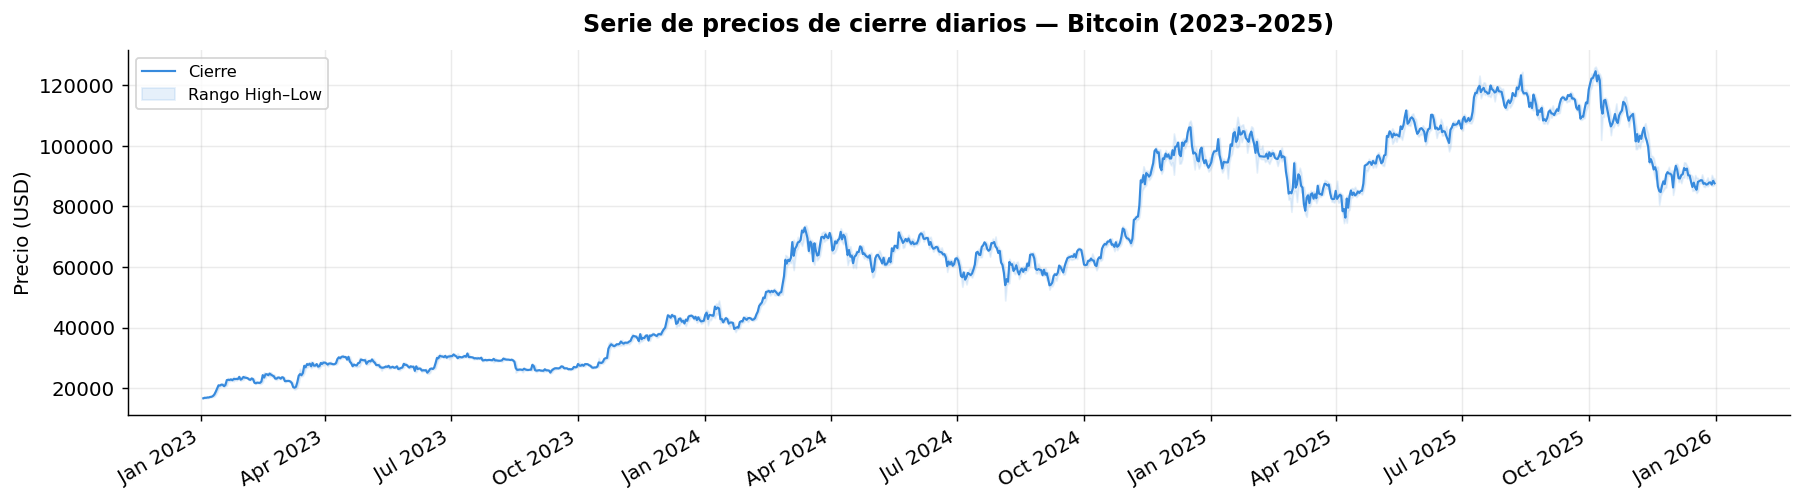

In [10]:
# grafica de serie de precios de cierre diarios 
fig, ax = plt.subplots(figsize=(14, 4))
 
ax.plot(df_daily.index, df_daily["close"],
        color=COLOR_PRICE, linewidth=1.2, label="Cierre")
ax.fill_between(df_daily.index, df_daily["low"], df_daily["high"],
                alpha=0.12, color=COLOR_PRICE, label="Rango High–Low")
 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_title("Serie de precios de cierre diarios — Bitcoin (2023–2025)",
             fontweight="bold", pad=10)
ax.set_ylabel("Precio (USD)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

- Análisis de Serie Temporal: Precios de Cierre de Bitcoin (2023-2025)

La serie temporal analizada comprende el periodo desde **enero de 2023 hasta enero de 2026**, mostrando una evolución desde los $18,000 USD hasta alcanzar un máximo histórico por encima de los $120,000 USD. El comportamiento general es de una tendencia alcista robusta con ciclos de expansión parabólica.

- Segmentación de la Tendencia

    El movimiento del precio se puede categorizar en tres fases distintas:
    - **Fase de Acumulación (2023)**: Crecimiento orgánico y constante. El activo rompe la lateralidad inicial y establece una base sólida por encima de los $30,000 USD hacia finales del tercer trimestre.
    - **Fase de Aceleración (2024):** Incremento de la pendiente de la curva. Se observan correcciones técnicas saludables que validan niveles de soporte previos (especialmente en el rango de los $60,000 USD).
    - **Fase de Euforia y Clímax (2025):** Movimiento parabólico hacia el **All-Time High (ATH)** cercano a los **$125,000 USD**. Esta etapa se caracteriza por una mayor verticalidad en los retornos diarios.

- Análisis de Volatilidad y Rango (High-Low)

    El **Rango High-Low** (sombreado azul) actúa como un indicador de la incertidumbre y la liquidez en el mercado:
    1.  **Expansión de Volatilidad:** Existe una correlación positiva entre el nivel de precio y el rango diario; a mayor precio, las oscilaciones intradía se vuelven más amplias en términos nominales.
    2.  **Presión de Venta:** En el último trimestre de 2025, el ensanchamiento del rango durante la caída sugiere una alta volatilidad de salida (toma de ganancias agresiva).

- Niveles Técnicos Clave

* **Soporte Estructural:** La zona de los **$60,000 - $70,000 USD** pasó de ser una resistencia psicológica a un suelo operativo durante 2024.
* **Resistencia Histórica:** El techo de mercado se estableció en el umbral de los **$125,000 USD**.
* **Estado reciente (Enero 2026):** La serie muestra una fase correctiva tras el agotamiento de la tendencia alcista, buscando soporte actualmente en la zona de los **$90,000 USD**.

El activo ha completado un ciclo de apreciación de aproximadamente **590%** desde el punto mínimo del gráfico. La ruptura de la línea de tendencia acelerada a finales de 2025 indica un cambio en el régimen de mercado, pasando de una fase de descubrimiento de precios a una de consolidación o corrección macro.

analizamos el porcentaje de retornos logaritmicos 

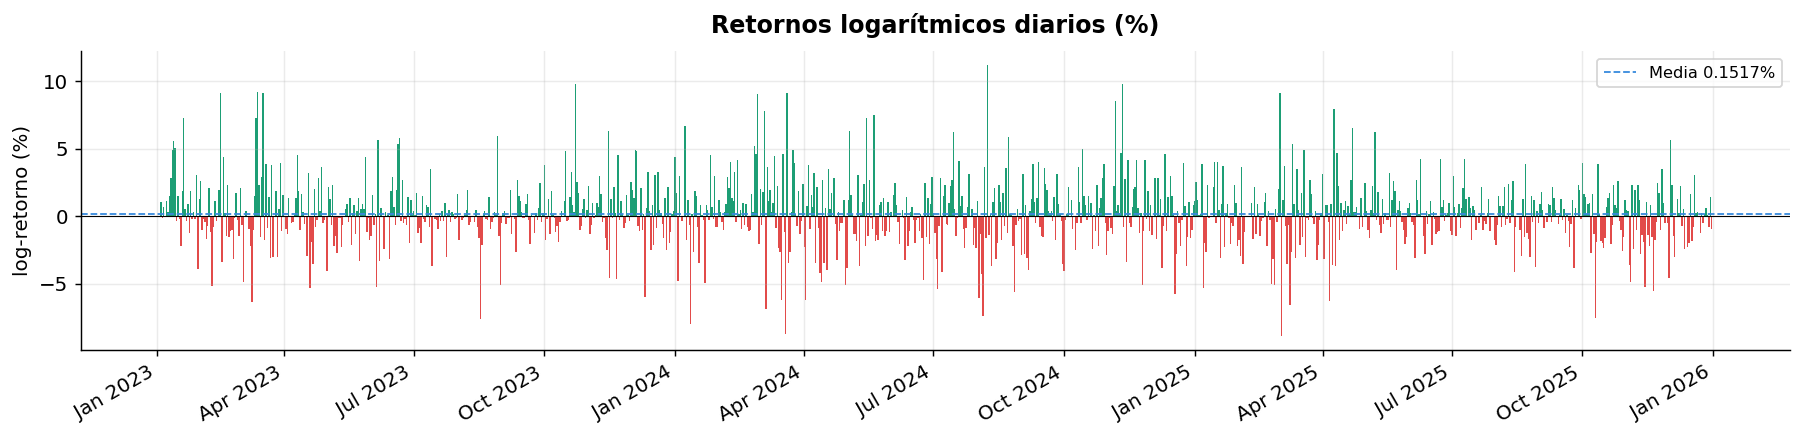

In [11]:
# Porcentaje de retornos logaritmicos 
colors_bar = [COLOR_POS if r >= 0 else COLOR_NEG for r in ret]
 
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(df_daily.index, ret * 100, color=colors_bar, width=1)
ax.axhline(0, color="black", linewidth=0.6)
ax.axhline( ret.mean() * 100, color=COLOR_PRICE, linewidth=1,
            linestyle="--", label=f"Media {ret.mean()*100:.4f}%")
 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_title("Retornos logarítmicos diarios (%)", fontweight="bold", pad=10)
ax.set_ylabel("log-retorno (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

- Análisis de Retornos Logarítmicos Diarios: Bitcoin (2023-2025)

- Comportamiento Estadístico Base

La gráfica de **log-retornos** permite observar la tasa de cambio continua del activo, eliminando el sesgo del precio nominal.
* **Media Diaria:** Se sitúa en **0.1517%**, lo cual confirma el sesgo alcista (bullish bias) de la serie en el largo plazo.
* **Distribución:** La serie muestra una alternancia constante entre retornos positivos (verde) y negativos (rojo), con una presencia notable de "colas pesadas" (eventos extremos).


- Volatilidad y Agrupamiento (Volatility Clustering)

Se identifica claramente el fenómeno de *Volatility Clustering*, donde periodos de alta volatilidad son seguidos por periodos de alta volatilidad:
* **Picos de Volatilidad (2024 - Q1 2025):** Durante el ascenso hacia el máximo histórico, se observan retornos diarios que superan el **±5%** con frecuencia, llegando incluso a picos puntuales cercanos al **10%**.
* **Estabilización Relativa:** Hacia finales de 2025, a pesar de la tendencia bajista en el precio, los retornos muestran una ligera disminución en la amplitud de las barras en comparación con los picos de euforia de mediados de año.

- Asimetría de los Retornos

* **Outliers Positivos:** El retorno máximo diario roza el **11%** (aproximadamente en julio de 2024), lo que coincide con rupturas de resistencias clave observadas en la gráfica de precios.
* **Outliers Negativos:** Se registran caídas diarias de hasta un **-8%**. Es notable que, durante 2025, los retornos negativos son más profundos y frecuentes que en 2023, lo que refleja una mayor presión de venta en niveles de precio elevados.

- Interpretación Financiera

1.  **Eficiencia del Mercado:** La fluctuación constante alrededor de la media sugiere un proceso estocástico con reversión a la media en la volatilidad, aunque el precio siga una tendencia.
2.  **Relación Riesgo-Retorno:** Una media de 0.15% diaria es significativamente alta para mercados tradicionales, pero viene acompañada de una desviación estándar (volatilidad) considerable, visible en la dispersión de las barras verticales.

Los retornos logarítmicos confirman que, aunque la tendencia de precio fue masivamente alcista, el camino estuvo marcado por "ruido" significativo y shocks de volatilidad. El hecho de que la media se mantenga positiva tras la corrección de finales de 2025 indica que el rendimiento acumulado del periodo sigue siendo robusto.

se analiza la distribucion de los retornos diarios 

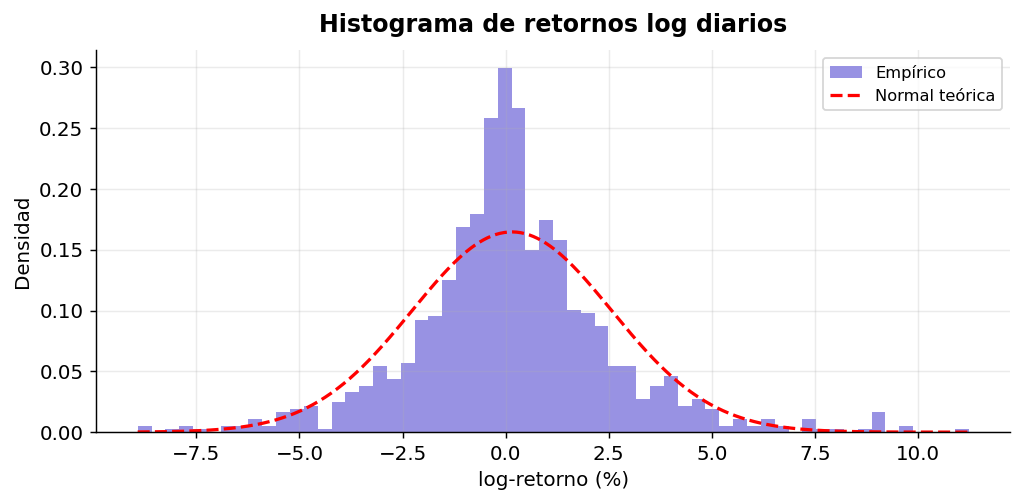

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
 
ax.hist(ret * 100, bins=60, density=True,
        color=COLOR_HIST, alpha=0.80, edgecolor="none", label="Empírico")
 
x = np.linspace((ret * 100).min(), (ret * 100).max(), 400)
ax.plot(x, stats.norm.pdf(x, (ret * 100).mean(), (ret * 100).std()),
        "r--", linewidth=1.8, label="Normal teórica")
 
ax.set_title("Histograma de retornos log diarios", fontweight="bold", pad=10)
ax.set_xlabel("log-retorno (%)")
ax.set_ylabel("Densidad")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Análisis de Distribución: Retornos Logarítmicos Diarios

Esta gráfica compara la distribución empírica de los retornos logarítmicos de un activo financiero (barras púrpuras) frente a una distribución normal teórica (línea punteada roja). A continuación, se detallan los hallazgos principales:
1. Forma de la Distribución (Leptocurtosis)

    - La característica más evidente es que los datos reales presentan un sesgo de curtosis positiva (distribución leptocúrtica).

    - Pico elevado: El histograma empírico es mucho más alto y estrecho en el centro (alrededor del 0%) que la curva normal. Esto indica que los retornos pequeños o nulos ocurren con más frecuencia de lo que predeciría un modelo normal.

    - Colas pesadas (Fat Tails): Se observan barras en los extremos (más allá de -7.5% y +10.0%) que se sitúan por encima de la línea roja. Esto sugiere la presencia de eventos extremos que la distribución normal subestima significativamente.

2. Tendencia Central

    - El centro de la masa de los datos está muy cerca de 0%, lo cual es estándar en retornos logarítmicos diarios para activos financieros, reflejando que, en el corto plazo, el cambio esperado promedio suele ser mínimo.

3. Simetría y Dispersión

    - Rango de Datos: Los retornos oscilan aproximadamente entre -9% y +11%.

    - Volatilidad: La curva normal teórica (línea roja) tiene una mayor dispersión (es más ancha) para intentar compensar los valores extremos, pero aun así no logra capturar correctamente la estructura de los datos reales en el centro.

4. Conclusiones para la Gestión de Riesgos

    Falla del supuesto de normalidad: Los datos demuestran que asumir una distribución normal para este activo sería arriesgado. El modelo normal subestima el riesgo de cola (pérdidas extremas).

    Modelado: Para una valoración más precisa (como el cálculo del Valor en Riesgo - VaR), sería más adecuado utilizar distribuciones que permitan colas pesadas, como la Distribución t de Student o modelos de volatilidad estocástica.

se analiza la distribucion de volatilidad 

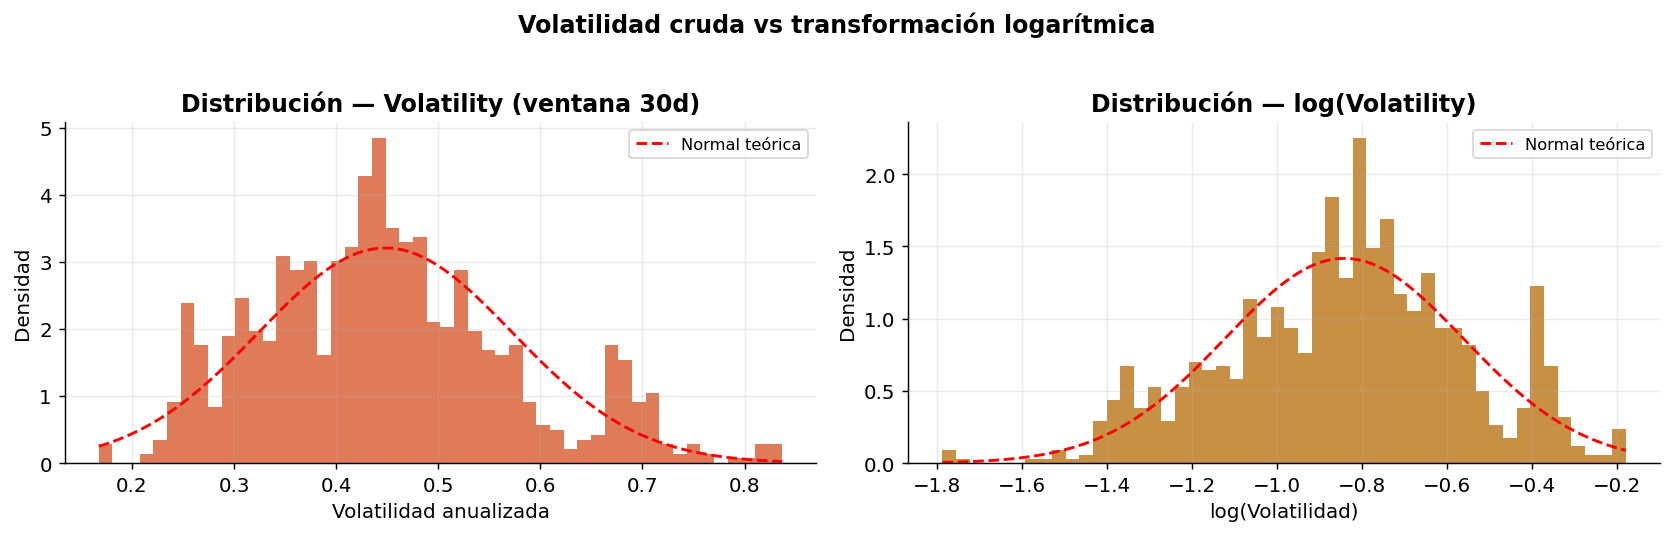

In [25]:
log_vol = np.log(vol)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
# Histograma volatilidad cruda
axes[0].hist(vol, bins=50, density=True, color=COLOR_VOLA,
             alpha=0.80, edgecolor="none")
x_v = np.linspace(vol.min(), vol.max(), 300)
axes[0].plot(x_v, stats.norm.pdf(x_v, vol.mean(), vol.std()),
             "r--", linewidth=1.6, label="Normal teórica")
axes[0].set_title(f"Distribución — Volatility (ventana {WINDOW_SIZE}d)",
                  fontweight="bold")
axes[0].set_xlabel("Volatilidad anualizada")
axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=9)
 
# Histograma log(volatilidad)
axes[1].hist(log_vol, bins=50, density=True, color=COLOR_ACF_SQ,
             alpha=0.80, edgecolor="none")
x_lv = np.linspace(log_vol.min(), log_vol.max(), 300)
axes[1].plot(x_lv, stats.norm.pdf(x_lv, log_vol.mean(), log_vol.std()),
             "r--", linewidth=1.6, label="Normal teórica")
axes[1].set_title("Distribución — log(Volatility)",
                  fontweight="bold")
axes[1].set_xlabel("log(Volatilidad)")
axes[1].set_ylabel("Densidad")
axes[1].legend(fontsize=9)
 
plt.suptitle("Volatilidad cruda vs transformación logarítmica",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- Análisis de Volatilidad — Bitcoin (Binance 2023–2025)

La gráfica compara:

- **Izquierda:** Volatilidad cruda (ventana de 30 días)
- **Derecha:** Transformación logarítmica de la volatilidad (log(volatility))

Este tipo de análisis es común en **finanzas cuantitativas** para evaluar la distribución y comportamiento del riesgo.

- 1 Volatilidad Cruda (Gráfica Izquierda)

    - Distribución **asimétrica hacia la derecha**
    - Mayor concentración entre **0.35 y 0.55**
    - Valores extremos hasta **0.80+**
    - Cola derecha larga (**fat tails**)

    - Interpretación

        Esto indica que:

        - La volatilidad normalmente es moderada
        - Existen **picos extremos ocasionales**
        - Estos picos reflejan eventos de mercado importantes

    - Conclusión Técnica

        -  No sigue distribución normal
        - Presenta **skew positivo**
        - Tiene **fat tails**
        - Comportamiento típico de criptomonedas

- 2 Log(Volatility) (Gráfica Derecha)

    - Observaciones

        - Distribución más **simétrica**
        - Forma más cercana a **campana de Gauss**
        - Mejor ajuste a la **normal teórica**

    - Interpretación

        La transformación logarítmica:

        -  Reduce valores extremos
        -  Estabiliza la varianza
        -  Mejora modelado estadístico

        Esto sugiere que:

        **La volatilidad de Bitcoin sigue una distribución log-normal**

- 3 Implicaciones para Bitcoin (2023–2025)

    El comportamiento observado indica:

    -  Clustering de volatilidad
    - Eventos extremos frecuentes
    - Regímenes de alta y baja volatilidad
    - Comportamiento no lineal

Analizis de normalidad de retornos

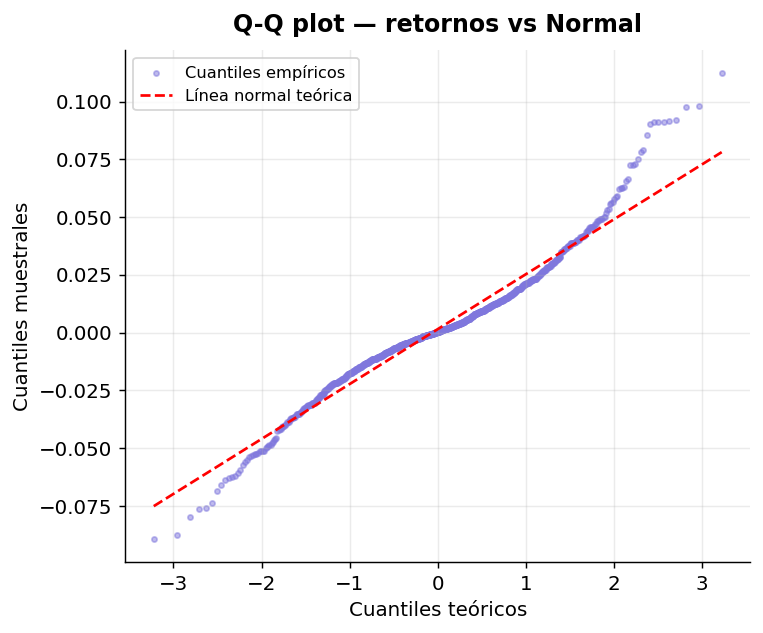

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
(osm, osr), (slope, intercept, _) = stats.probplot(ret, dist="norm")
 
ax.scatter(osm, osr, s=8, alpha=0.5, color=COLOR_HIST, label="Cuantiles empíricos")
ax.plot(osm, slope * np.array(osm) + intercept,
        "r--", linewidth=1.5, label="Línea normal teórica")
 
ax.set_title("Q-Q plot — retornos vs Normal", fontweight="bold", pad=10)
ax.set_xlabel("Cuantiles teóricos")
ax.set_ylabel("Cuantiles muestrales")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

- Análisis de Normalidad: Q-Q Plot de Retornos vs. Distribución Normal

- Descripción del Gráfico
El gráfico **Q-Q (Quantile-Quantile)** compara los cuantiles empíricos de los retornos de Bitcoin con los cuantiles teóricos de una **distribución normal** (línea roja discontinua). 

- Diagnóstico de la Distribución
Al observar la desviación de los puntos (cuantiles muestrales) respecto a la línea de referencia, se identifican las siguientes características:

* **Colas Pesadas (Fat Tails):** Los puntos en ambos extremos se alejan significativamente de la línea roja. 
    * En el **extremo izquierdo** (valores negativos), los puntos caen por debajo de la línea, indicando que los retornos negativos extremos son más frecuentes de lo que predeciría una distribución normal.
    * En el **extremo derecho** (valores positivos), los puntos suben por encima de la línea, indicando que los retornos positivos altos también son más comunes de lo esperado.
* **Comportamiento en el Centro:** En la zona central (entre los cuantiles teóricos -1 y 1), los puntos siguen de cerca la línea roja, lo que sugiere que para movimientos pequeños y moderados, el comportamiento se aproxima a la normalidad.

- Implicaciones Estadísticas
    1.  **Presencia de Curtosis Elevada:** La forma de "S" invertida es un indicador clásico de una distribución **leptocúrtica**. Esto significa que los retornos tienen un pico más alto en la media y colas mucho más gruesas que la normal.
    2.  **Riesgo de Eventos Extremos (Black Swans):** El gráfico demuestra que el modelo normal subestima sistemáticamente la probabilidad de movimientos bruscos (tanto caídas como subidas). En términos financieros, el riesgo es mayor al calculado por modelos que asumen normalidad.

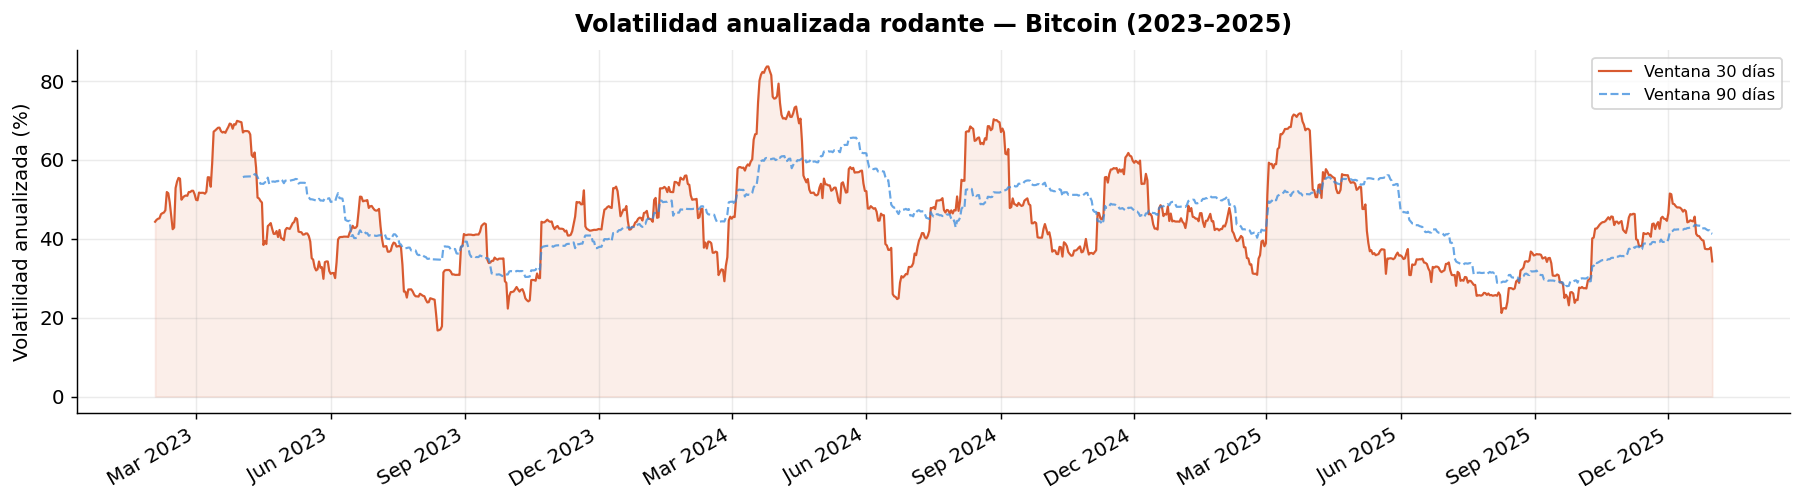

In [15]:
vol_30  = ret.rolling(30).std()  * np.sqrt(365) * 100
vol_90  = ret.rolling(90).std()  * np.sqrt(365) * 100
 
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_daily.index, vol_30, color=COLOR_VOLA, linewidth=1.2, label="Ventana 30 días")
ax.plot(df_daily.index, vol_90, color=COLOR_PRICE, linewidth=1.2,
        linestyle="--", alpha=0.75, label="Ventana 90 días")
ax.fill_between(df_daily.index, vol_30, alpha=0.10, color=COLOR_VOLA)
 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_title("Volatilidad anualizada rodante — Bitcoin (2023–2025)",
             fontweight="bold", pad=10)
ax.set_ylabel("Volatilidad anualizada (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

La gráfica muestra la **volatilidad anualizada de Bitcoin** calculada a partir de **retornos diarios**, utilizando dos ventanas móviles:
- **30 días** (línea sólida): capta cambios de corto plazo.
- **90 días** (línea discontinua): refleja tendencias de volatilidad de mediano plazo.

Observaciones principales

- Diferencias entre ventanas
- La **ventana de 30 días** es notablemente más **reactiva**, con picos y caídas abruptas.
- La **ventana de 90 días** es más **suave y estable**, actuando como una señal de régimen de volatilidad.

Esto es consistente con la teoría: ventanas más cortas responden rápido a shocks, mientras que las largas amortiguan el ruido.

Regímenes de volatilidad

Se observan **clústeres de volatilidad**, es decir, períodos prolongados donde la volatilidad se mantiene alta o baja:

- **Alta volatilidad**:
  - Primer semestre de **2023**.
  - Picos marcados en **Q2–Q3 de 2024**, donde la volatilidad a 30 días supera el **80% anualizado**.
  - Episodios recurrentes en **inicios de 2025**.

- **Baja volatilidad**:
  - Finales de **2023**.
  - Mitad de **2025**, con valores cercanos al **25–30%** en la ventana corta.

Este comportamiento es típico de mercados financieros y sugiere **heterocedasticidad**.

Dinámica temporal
  - Los **picos en la ventana de 30 días suelen anticipar** incrementos posteriores en la ventana de 90 días.
  - Esto indica que los shocks de corto plazo **se propagan gradualmente** al riesgo de mediano plazo.
  - La reversión es más lenta en la ventana larga, lo que refuerza la idea de persistencia de la volatilidad.

Comparación interanual
  - **2023**: volatilidad moderada, con episodios puntuales de estrés.
  - **2024**: año más inestable, con los **máximos niveles de volatilidad del período**.
  - **2025**: tendencia general a la **normalización**, aunque con repuntes transitorios.

Implicaciones analíticas

  - La presencia de clústeres sugiere que modelos con **varianza condicional** (ARCH/GARCH) serían apropiados.
  - La diferencia entre ventanas indica que el **riesgo depende fuertemente del horizonte temporal**.
  - Para trading o gestión de riesgo:
      - Ventana corta → útil para **timing y señales tácticas**.
      - Ventana larga → mejor para **asignación estratégica y control de riesgo**.

La gráfica confirma que la volatilidad de Bitcoin es **dinámica, persistente y dependiente del régimen**, con shocks de corto plazo que impactan gradualmente el riesgo de mediano plazo. Esto refuerza la necesidad de enfoques de modelado que capturen **dependencia temporal y heterocedasticidad**.

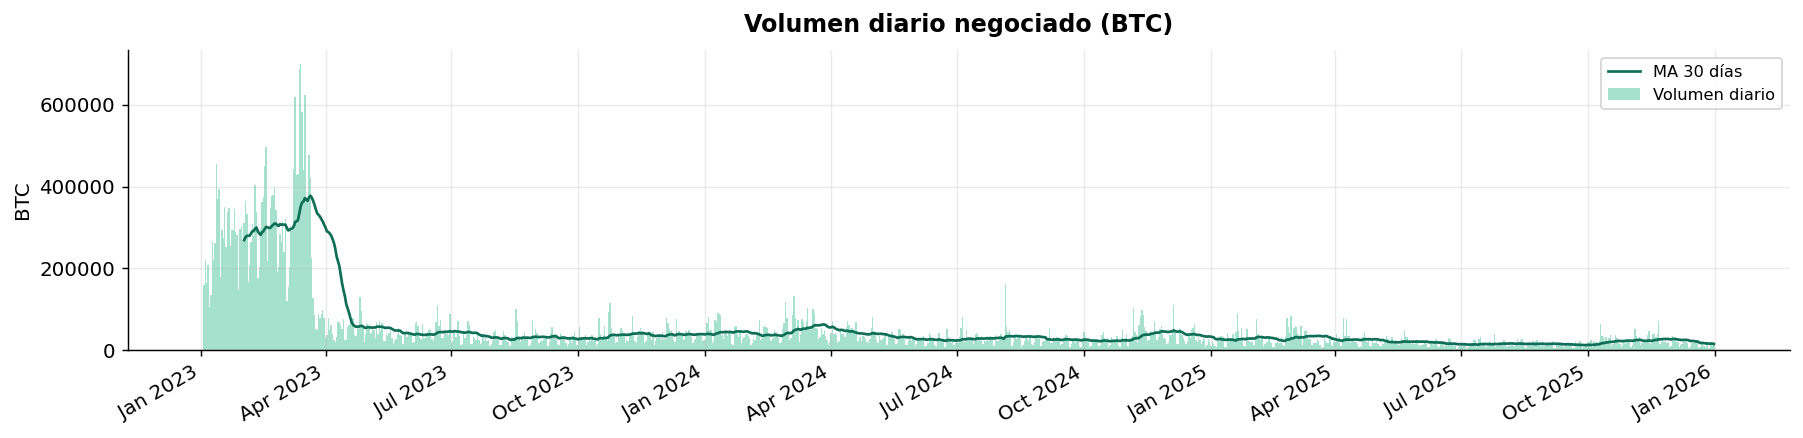

In [16]:
vol_ma30 = df_daily["volume"].rolling(30).mean()
 
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(df_daily.index, df_daily["volume"], color=COLOR_VOL,
       alpha=0.55, width=1, label="Volumen diario")
ax.plot(df_daily.index, vol_ma30, color="#0F6E56", linewidth=1.5,
        label="MA 30 días")
 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_title("Volumen diario negociado (BTC)", fontweight="bold", pad=10)
ax.set_ylabel("BTC")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

La gráfica presenta el **volumen diario nominal en BTC** (barras verde claro) y su **media móvil simple de 30 días (MA 30)** (línea verde oscura), lo que permite filtrar el ruido diario y observar la tendencia de liquidez.

* **Anomalía de Inicio (Q1 2023):** Se observa un pico masivo de volumen entre enero y marzo de 2023, superando los **600,000 BTC diarios**. Este evento suele estar asociado a grandes rebalanceos de carteras, eventos de capitulación o cambios significativos en la estructura de comisiones de los exchanges.
* **Estabilización Post-Pico:** Tras abril de 2023, el volumen nominal cae drásticamente y se mantiene en niveles relativamente bajos y constantes (por debajo de los 100,000 BTC diarios) durante el resto del periodo.

- Relación Volumen-Precio

    Al contrastar con la gráfica de precios, se identifica una divergencia interesante:
    1.  **Volumen Seco en el Rally:** A pesar de que el precio de Bitcoin subió de manera parabólica en 2024 y 2025, el volumen medido en **unidades de BTC** fue disminuyendo o manteniéndose plano.
    2.  **Interpretación:** Esto sugiere que, a medida que el precio unitario aumenta, se requieren menos Bitcoin para mover la misma cantidad de capital fiduciario (USD). También puede indicar una fase de "HODLing" (baja oferta circulante), donde el precio sube con relativamente pocas transacciones en cadena.

- Picos de Actividad Puntuales

    Existen repuntes aislados de volumen (spikes) a lo largo de 2024 y 2025 que coinciden con:
    * **Correcciones Técnicas:** Los picos suelen ocurrir en días de retornos negativos extremos, lo que valida la presencia de presión vendedora fuerte en niveles de resistencia.
    * **Rupturas de Máximos:** Incrementos leves de la MA 30 durante los periodos de expansión de precio, confirmando el interés institucional o minorista en momentos críticos.

- Análisis de la Media Móvil (MA 30)
    La línea de la media móvil muestra una pendiente negativa prolongada desde mediados de 2023 hasta finales de 2025. 
    * Esta tendencia indica una **consolidación de la liquidez**. 
    * Hacia enero de 2026, el volumen se encuentra en niveles mínimos históricos para la serie, lo cual suele preceder a movimientos de precios bruscos (un mercado "seco" es más susceptible a la volatilidad).
    
- Conclusión Técnica

El volumen negociado en BTC muestra una **disminución estructural** conforme el ciclo avanza. Mientras que el precio alcanzó máximos históricos, el volumen nominal no acompañó este crecimiento, indicando que el rally de 2025 fue impulsado por una baja liquidez relativa o un incremento masivo en el valor fiduciario de cada unidad transaccionada, más que por un incremento en la cantidad de activos intercambiados.

### Analisis de Test y outliers 

se realiza el test ADF para determinar si la serie es estacionaria 

TEST DE ESTACIONARIEDAD

── ADF — Precio de cierre ──
  Estadístico : -1.3954
  p-value     : 5.8447e-01
  Valor crítico 1%: -3.4364
  Valor crítico 5%: -2.8642
  Valor crítico 10%: -2.5682
  → NO estacionaria ✗

── KPSS — Precio de cierre ──
  Estadístico : 4.9461
  p-value     : 0.0100  (lags=20)
  → NO estacionaria ✗

── ADF — Retornos log diarios ──
  Estadístico : -34.2566
  p-value     : 0.0000e+00
  Valor crítico 1%: -3.4363
  Valor crítico 5%: -2.8642
  Valor crítico 10%: -2.5682
  → ESTACIONARIA ✓

── KPSS — Retornos log diarios ──
  Estadístico : 0.3042
  p-value     : 0.1000  (lags=3)
  → ESTACIONARIA ✓


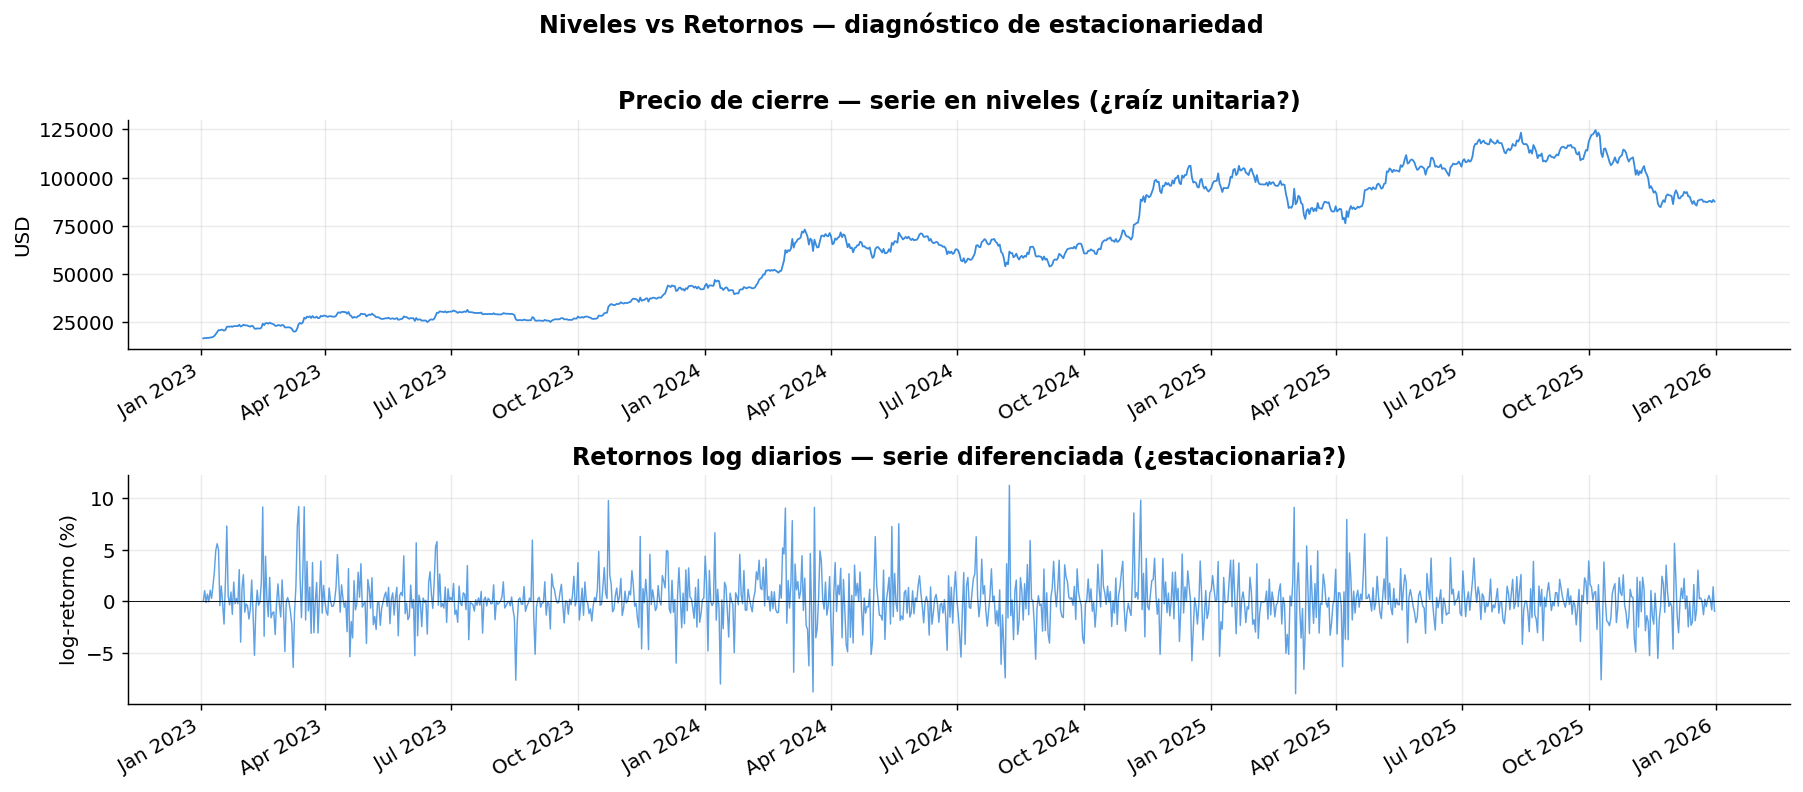

In [17]:
def run_adf(series, nombre):
    res = adfuller(series.dropna(), autolag="AIC")
    print(f"\n── ADF — {nombre} ──")
    print(f"  Estadístico : {res[0]:.4f}")
    print(f"  p-value     : {res[1]:.4e}")
    for k, v in res[4].items():
        print(f"  Valor crítico {k}: {v:.4f}")
    conclusion = "ESTACIONARIA " if res[1] < 0.05 else "NO estacionaria "
    print(f"  → {conclusion}")
 
def run_kpss(series, nombre):
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore")
        stat, p, lags, crits = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\n── KPSS — {nombre} ──")
    print(f"  Estadístico : {stat:.4f}")
    print(f"  p-value     : {p:.4f}  (lags={lags})")
    conclusion = "NO estacionaria " if p < 0.05 else "ESTACIONARIA "
    print(f"  → {conclusion}")
 
print("=" * 55)
print("TEST DE ESTACIONARIEDAD")
print("=" * 55)
 
for serie, nombre in [
    (df_daily["close"], "Precio de cierre"),
    (ret,               "Retornos log diarios"),
]:
    run_adf(serie, nombre)
    run_kpss(serie, nombre)
 
# Visualización: precio en niveles vs retornos (estacionariedad visual)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
 
axes[0].plot(df_daily.index, df_daily["close"], color=COLOR_PRICE, linewidth=1)
axes[0].set_title("Precio de cierre — serie en niveles (¿raíz unitaria?)",
                  fontweight="bold")
axes[0].set_ylabel("USD")
 
axes[1].plot(df_daily.index, ret * 100, color=COLOR_ACF, linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Retornos log diarios — serie diferenciada (¿estacionaria?)",
                  fontweight="bold")
axes[1].set_ylabel("log-retorno (%)")
 
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
 
plt.suptitle("Niveles vs Retornos — diagnóstico de estacionariedad",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Test de Estacionariedad – Análisis e Interpretación

A partir de los resultados obtenidos con los tests **ADF (Augmented Dickey–Fuller)** y **KPSS**, se puede realizar un diagnóstico consistente sobre la naturaleza estocástica de las series analizadas.

---

- Precio de cierre

    - ADF – Precio de cierre
        - **Hipótesis nula (H₀):** la serie presenta raíz unitaria (no es estacionaria).
        - El estadístico ADF (**-1.3954**) es mayor que los valores críticos al 1%, 5% y 10%.
        - El **p-value = 0.584**, claramente superior a 0.05.

    **Conclusión:**  
    No se rechaza la hipótesis nula → el precio de cierre **no es estacionario**.

    - KPSS – Precio de cierre
    - **Hipótesis nula (H₀):** la serie es estacionaria.
    - El estadístico KPSS (**4.9461**) es elevado.
    - El **p-value = 0.01**, menor que 0.05.

    **Conclusión:**  
`   Se rechaza la hipótesis nula → el precio de cierre **no es estacionario**.

- Interpretación conjunta

    Ambos tests coinciden en que el precio de cierre presenta una **raíz unitaria**, lo que indica un comportamiento de tipo *random walk*, típico de los precios de activos financieros.
    
    **Implicación:**  
    
    No es apropiado modelar el precio en niveles con modelos que asumen estacionariedad. Se requiere una transformación, como diferenciación o el uso de retornos.

- Retornos logarítmicos diarios

    - ADF – Retornos logarítmicos
        - **Hipótesis nula (H₀):** la serie tiene raíz unitaria.
        - El estadístico ADF (**-34.2566**) es muy inferior a todos los valores críticos.
        - El **p-value ≈ 0**, lo que indica fuerte evidencia estadística.

    **Conclusión:**  
    Se rechaza la hipótesis nula → los retornos **son estacionarios**.

    - KPSS – Retornos logarítmicos
        - **Hipótesis nula (H₀):** la serie es estacionaria.
        - El estadístico KPSS (**0.3042**) es bajo.
        - El **p-value = 0.10**, mayor que 0.05.

    **Conclusión:**  
    No se rechaza la hipótesis nula → los retornos **son estacionarios**.

- Resumen de resultados

| Serie                 | ADF             | KPSS            | Conclusión final |
|----------------------|-----------------|-----------------|------------------|
| Precio de cierre     | No estacionaria | No estacionaria | Raíz unitaria   |
| Retornos logarítmicos| Estacionaria    | Estacionaria    | Estacionaria    |

La coherencia entre ADF y KPSS refuerza la robustez del diagnóstico.

- Interpretación financiera

    Los resultados son consistentes con la teoría financiera:
    - Los **precios** siguen un proceso no estacionario, cercano a un *random walk*.
    - Los **retornos** son estacionarios, con media constante, aunque pueden presentar **heterocedasticidad condicional**.

    Esto sugiere que la predictibilidad no se encuentra en el nivel de precios, sino potencialmente en la dinámica de la volatilidad.

Se analiza la autocorrelacion para los retornos y la volatilidad

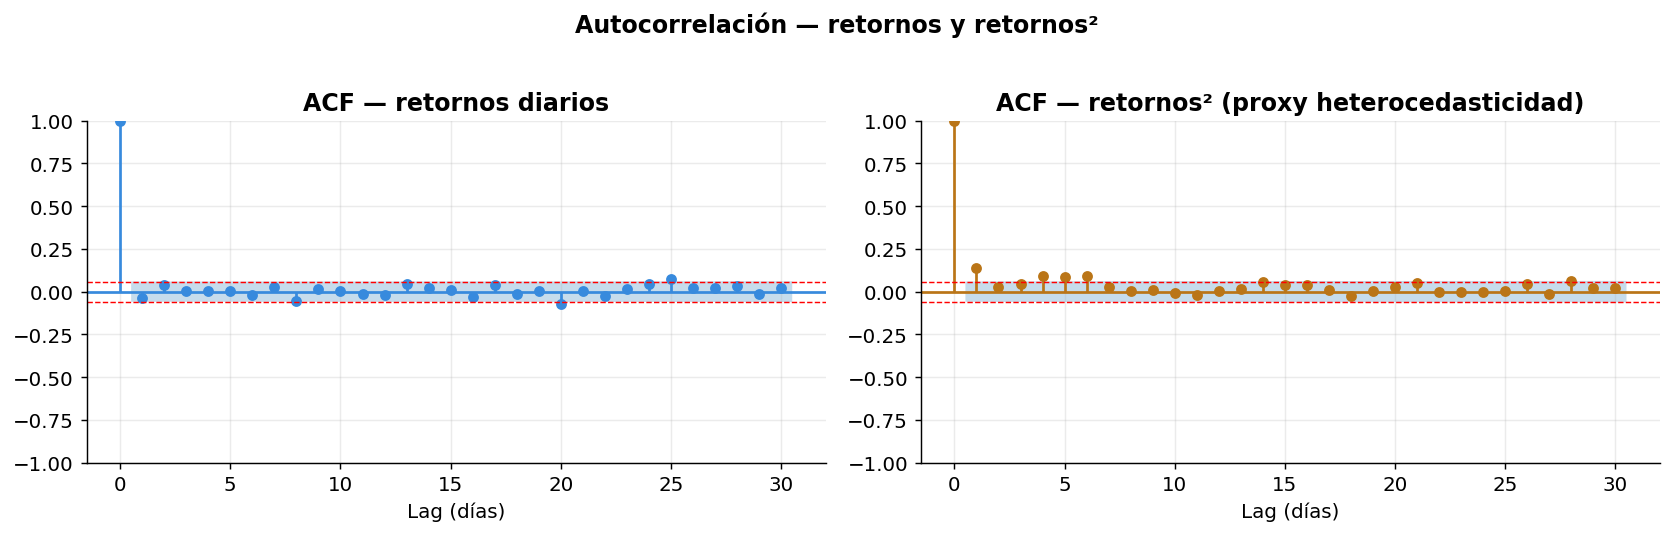

In [28]:
LAGS   = 30
BAND   = 1.96 / np.sqrt(n)   # banda de confianza 95 %
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
plot_acf(ret, lags=LAGS, ax=axes[0], alpha=0.05,
         color=COLOR_ACF, vlines_kwargs={"colors": COLOR_ACF})
axes[0].set_title("ACF — retornos diarios", fontweight="bold")
axes[0].set_xlabel("Lag (días)")
axes[0].axhline( BAND, color="red", linestyle="--", linewidth=0.8)
axes[0].axhline(-BAND, color="red", linestyle="--", linewidth=0.8)
 
plot_acf(ret**2, lags=LAGS, ax=axes[1], alpha=0.05,
         color=COLOR_ACF_SQ, vlines_kwargs={"colors": COLOR_ACF_SQ})
axes[1].set_title("ACF — retornos² (proxy heterocedasticidad)", fontweight="bold")
axes[1].set_xlabel("Lag (días)")
axes[1].axhline( BAND, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(-BAND, color="red", linestyle="--", linewidth=0.8)
 
plt.suptitle("Autocorrelación — retornos y retornos²", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- Análisis de Autocorrelación — Retornos y Retornos² (Bitcoin)

La figura presenta la **función de autocorrelación (ACF)** para:
- **Retornos diarios** (izquierda).
- **Retornos diarios al cuadrado** (derecha), usados como *proxy* de **heterocedasticidad**.

Las líneas rojas punteadas representan los **límites de significancia estadística** (≈95%).

- ACF de retornos diarios

    **Observaciones clave:**
    - La mayoría de los coeficientes (lags 1–30) se encuentran **dentro de los límites de significancia**.
    - No se observa un patrón sistemático de autocorrelación positiva o negativa.
    - Algunos picos aislados aparecen cercanos al umbral, pero **no son persistentes**.

    **Interpretación:**
    - Los retornos diarios son **aproximadamente no autocorrelacionados**.
    - Esto es consistente con la **hipótesis de eficiencia débil del mercado**.
    - Modelos AR simples sobre retornos tendrían **bajo poder explicativo**.

- ACF de retornos² (heterocedasticidad)

    **Observaciones clave:**
    - Varios lags iniciales (≈ 1–10) muestran **autocorrelación positiva y significativa**.
    - La autocorrelación decae lentamente a medida que aumenta el lag.
    - Existe una **estructura persistente** en la varianza.

    **Interpretación:**
    - Evidencia clara de **clustering de volatilidad**.
    - La varianza condicional **no es constante** (heterocedasticidad).
    - Choques de alta volatilidad tienden a ser seguidos por periodos similares.

- Implicaciones para el modelado

    - **Media**:
        - Retornos ≈ ruido blanco → modelos ARMA simples son suficientes o incluso innecesarios.
    - **Varianza**:
        - Dependencia temporal fuerte → modelos **ARCH/GARCH** son apropiados.
        - Alternativas: EGARCH, GJR-GARCH para capturar asimetrías.

- Conclusión

La gráfica confirma un patrón típico de series financieras:
- **Retornos no autocorrelacionados** en la media.
- **Varianza altamente autocorrelacionada** en el tiempo.

Esto justifica un enfoque de modelado donde la dinámica principal se concentra en la **volatilidad**, más que en la predicción directa de los retornos.

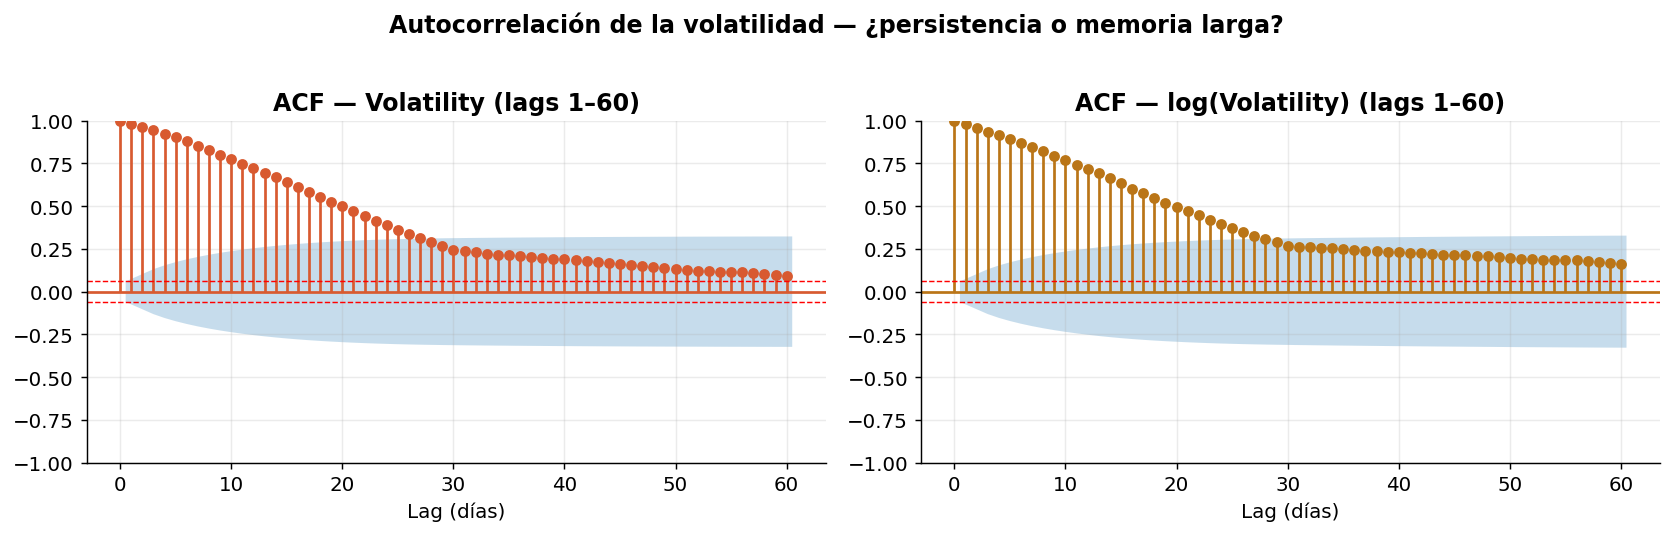

In [26]:
LAGS_VOL = 60   # más lags que para retornos: la volatilidad es más persistente
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
plot_acf(vol, lags=LAGS_VOL, ax=axes[0], alpha=0.05,
         color=COLOR_VOLA, vlines_kwargs={"colors": COLOR_VOLA})
axes[0].set_title(f"ACF — Volatility (lags 1–{LAGS_VOL})", fontweight="bold")
axes[0].set_xlabel("Lag (días)")
axes[0].axhline( 1.96 / np.sqrt(len(vol)), color="red",
                linestyle="--", linewidth=0.8)
axes[0].axhline(-1.96 / np.sqrt(len(vol)), color="red",
                linestyle="--", linewidth=0.8)
 
plot_acf(log_vol, lags=LAGS_VOL, ax=axes[1], alpha=0.05,
         color=COLOR_ACF_SQ, vlines_kwargs={"colors": COLOR_ACF_SQ})
axes[1].set_title(f"ACF — log(Volatility) (lags 1–{LAGS_VOL})", fontweight="bold")
axes[1].set_xlabel("Lag (días)")
axes[1].axhline( 1.96 / np.sqrt(len(log_vol)), color="red",
                linestyle="--", linewidth=0.8)
axes[1].axhline(-1.96 / np.sqrt(len(log_vol)), color="red",
                linestyle="--", linewidth=0.8)
 
plt.suptitle("Autocorrelación de la volatilidad — ¿persistencia o memoria larga?",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

La gráfica muestra la **Autocorrelación (ACF)** de:

- **Izquierda:** Volatilidad (ventana 30 días)
- **Derecha:** Log(Volatilidad)

El objetivo es analizar si la volatilidad de Bitcoin presenta:

- Persistencia
- Clustering de volatilidad
- Memoria larga (long memory)

-  ACF — Volatilidad (Gráfica Izquierda)

    - Observaciones

        - Autocorrelación **muy alta en lags cortos** (~0.95–1.0)
        - Decaimiento **lento y progresivo**
        - Autocorrelación positiva incluso en **lag 60 días**
        - Valores significativamente fuera del intervalo de confianza

    - Interpretación

        Esto indica:

        - **Alta persistencia de volatilidad**
        - Clustering de volatilidad (periodos tranquilos y turbulentos agrupados)
        - La volatilidad depende fuertemente de su pasado

        Esto significa que:

        - Si la volatilidad es alta hoy → probablemente seguirá alta
        - Si la volatilidad es baja hoy → probablemente seguirá baja

        Esto es **característico de mercados financieros**, especialmente cripto.

- ACF — log(Volatility) (Gráfica Derecha)

    - Observaciones

        - Patrón muy similar pero **más estable**
        - Decaimiento más suave
        - Persistencia significativa hasta lag 60
        - Autocorrelación siempre positiva

    - Interpretación

        Esto sugiere:

        - Log-volatility presenta **memoria más estructurada**
        - Mejor comportamiento para modelado estadístico
        - Ideal para modelos GARCH y volatilidad estocástica

-  Hallazgo Clave: Memoria Larga

    La autocorrelación decrece lentamente, lo que sugiere:

    - **Long Memory Process**
    - Dependencia de largo plazo
    - Persistencia estructural del riesgo

    Esto es muy común en:

    - Mercados financieros
    - Criptomonedas
    - Series temporales de volatilidad

- Implicaciones Cuantitativas

    Esto significa que:

    - La volatilidad es **predecible parcialmente**
    - El pasado contiene información útil
    - Existen **regímenes de volatilidad**

-  Conclusiones Clave

    - Alta persistencia de volatilidad
    - Evidencia de clustering de volatilidad
    - Memoria larga en Bitcoin
    - Log(volatilidad) más estable para modelado
    - Volatilidad parcialmente predecible


    Este resultado confirma que:

    - Bitcoin presenta **volatility clustering**
    - La volatilidad tiene **memoria larga**
    - El riesgo no es aleatorio
    - Existen **regímenes de mercado claros**

    Esto es fundamental para:

    - Trading cuantitativo
    - Modelos predictivos
    - Gestión de riesgo
    - Machine learning financiero

TEST DE LJUNG-BOX — RETORNOS
H0: no hay autocorrelación hasta el lag k
    lb_stat  lb_pvalue
15  11.4549     0.7197
30  31.5839     0.3871
60  58.7705     0.5207
90  94.0657     0.3639

TEST DE LJUNG-BOX — RETORNOS² (efectos ARCH)
H0: no hay autocorrelación hasta el lag k
     lb_stat  lb_pvalue
15   57.0823     0.0000
30   71.8951     0.0000
60   93.1477     0.0039
90  134.3618     0.0017


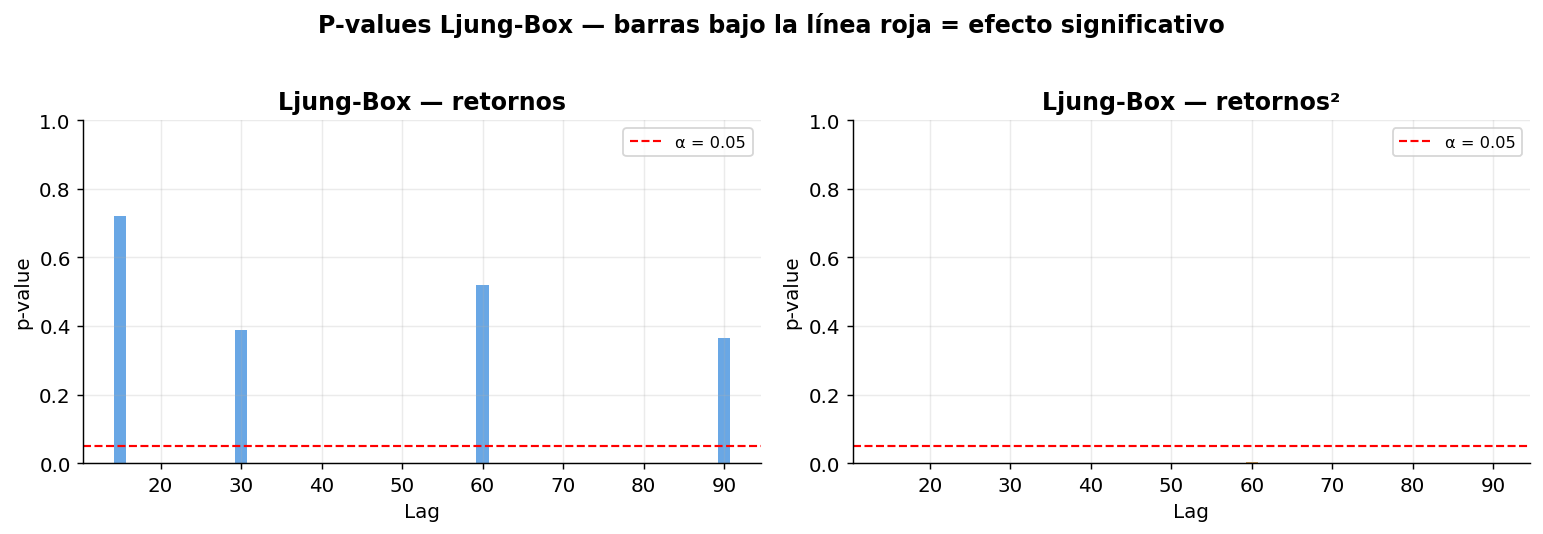

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 13 — Test de Ljung-Box (efectos ARCH formales)
# ─────────────────────────────────────────────────────────────────────────────
# Ljung-Box sobre retornos  → ¿hay autocorrelación en la media?
# Ljung-Box sobre retornos² → ¿hay efectos ARCH (volatilidad agrupada)?
 
LAGS_LB = [15,30,60,90]
 
lb_ret  = acorr_ljungbox(ret,    lags=LAGS_LB, return_df=True)
lb_ret2 = acorr_ljungbox(ret**2, lags=LAGS_LB, return_df=True)
 
print("=" * 55)
print("TEST DE LJUNG-BOX — RETORNOS")
print("H0: no hay autocorrelación hasta el lag k")
print("=" * 55)
print(lb_ret[["lb_stat", "lb_pvalue"]].round(4).to_string())
 
print("\n" + "=" * 55)
print("TEST DE LJUNG-BOX — RETORNOS² (efectos ARCH)")
print("H0: no hay autocorrelación hasta el lag k")
print("=" * 55)
print(lb_ret2[["lb_stat", "lb_pvalue"]].round(4).to_string())
 
# Visualización: p-values de Ljung-Box por lag
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for ax, lb, title, color in [
    (axes[0], lb_ret,  "Ljung-Box — retornos",   COLOR_ACF),
    (axes[1], lb_ret2, "Ljung-Box — retornos²",  COLOR_ACF_SQ),
]:
    ax.bar(lb.index, lb["lb_pvalue"], color=color, alpha=0.75, width=1.5)
    ax.axhline(0.05, color="red", linestyle="--", linewidth=1.2,
               label="α = 0.-05")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Lag")
    ax.set_ylabel("p-value")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
 
plt.suptitle("P-values Ljung-Box — barras bajo la línea roja = efecto significativo",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- Análisis del Test de Ljung–Box — **Retornos**

**Hipótesis nula (H₀):** no existe autocorrelación en los retornos hasta el lag *k*.

- Resultados observados
  - Para los lags **15, 30, 60 y 90**, todos los **p-values son mayores que α = 0.05**.
  - En la gráfica, **ninguna barra cruza la línea roja**, lo que indica ausencia de significancia estadística.
  - Los valores reportados confirman esto:
    - Lag 15 → p-value = **0.7197**
    - Lag 30 → p-value = **0.3871**
    - Lag 60 → p-value = **0.5207**
    - Lag 90 → p-value = **0.3639**

- Interpretación
  - **No se rechaza H₀ en ningún lag analizado.**
  - Los retornos **no presentan autocorrelación lineal significativa**.
  - Esto es consistente con el comportamiento típico de series financieras:
    - Los retornos se aproximan a un **ruido blanco**.
  - Modelos ARMA complejos **no están justificados** para la media.

- Implicación para el modelado
  - La ecuación de media puede ser **constante o muy simple**.
  - El foco del modelado debe trasladarse a la **dinámica de la varianza**, no de la media.

- Análisis del Test de Ljung–Box — **Retornos² (Efectos ARCH)**

**Hipótesis nula (H₀):** no existe autocorrelación en los retornos al cuadrado hasta el lag *k*.

- Resultados observados
  - Para **todos los lags (15, 30, 60 y 90)**, los **p-values son menores que α = 0.05**.
  - En la gráfica, las barras están **muy por debajo de la línea roja**, indicando fuerte significancia estadística.
  - Valores reportados:
    - Lag 15 → p-value = **0.0000**
    - Lag 30 → p-value = **0.0000**
    - Lag 60 → p-value = **0.0039**
    - Lag 90 → p-value = **0.0017**

- Interpretación
  - **Se rechaza H₀ en todos los lags.**
  - Existe **autocorrelación significativa en los retornos²**.
  - Esto evidencia **heterocedasticidad condicional**:
    - La volatilidad no es constante.
    - Hay **clustering de volatilidad** (periodos de alta y baja varianza).

- Implicación para el modelado
  - La serie **sí presenta efectos ARCH/GARCH**.
  - Es apropiado utilizar modelos de volatilidad como:
    - **ARCH**
    - **GARCH**
    - **EGARCH / GJR-GARCH** (si hay asimetría)
  - Aunque la media sea ruido blanco, **la varianza es altamente predecible**.

- Conclusión conjunta
  - Retornos: **no autocorrelados**
  - Retornos²: **fuertemente autocorrelados**
  -  La predictibilidad del proceso está en la **volatilidad**, no en la media

se analizan los outliers

OUTLIERS — retornos fuera de ±3σ
Total detectados : 19
% sobre muestra  : 1.74%

                               close  log_ret  z_score
open_time                                             
2023-02-15 00:00:00+00:00   24324.05   0.0914   3.7090
2023-03-13 00:00:00+00:00   24113.48   0.0919   3.7288
2023-03-17 00:00:00+00:00   27395.13   0.0915   3.7155
2023-08-17 00:00:00+00:00   26623.41  -0.0762  -3.2064
2023-10-23 00:00:00+00:00   33069.99   0.0977   3.9690
2024-01-12 00:00:00+00:00   42782.73  -0.0799  -3.3585
2024-02-28 00:00:00+00:00   62432.10   0.0904   3.6675
2024-03-04 00:00:00+00:00   68245.71   0.0782   3.1639
2024-03-19 00:00:00+00:00   61937.40  -0.0876  -3.6795
2024-03-20 00:00:00+00:00   67840.51   0.0910   3.6948
2024-05-20 00:00:00+00:00   71446.62   0.0752   3.0392
2024-08-05 00:00:00+00:00   54018.81  -0.0739  -3.1120
2024-08-08 00:00:00+00:00   61685.99   0.1123   4.5719
2024-11-06 00:00:00+00:00   75571.99   0.0856   3.4705
2024-11-11 00:00:00+00:00   88647.99   

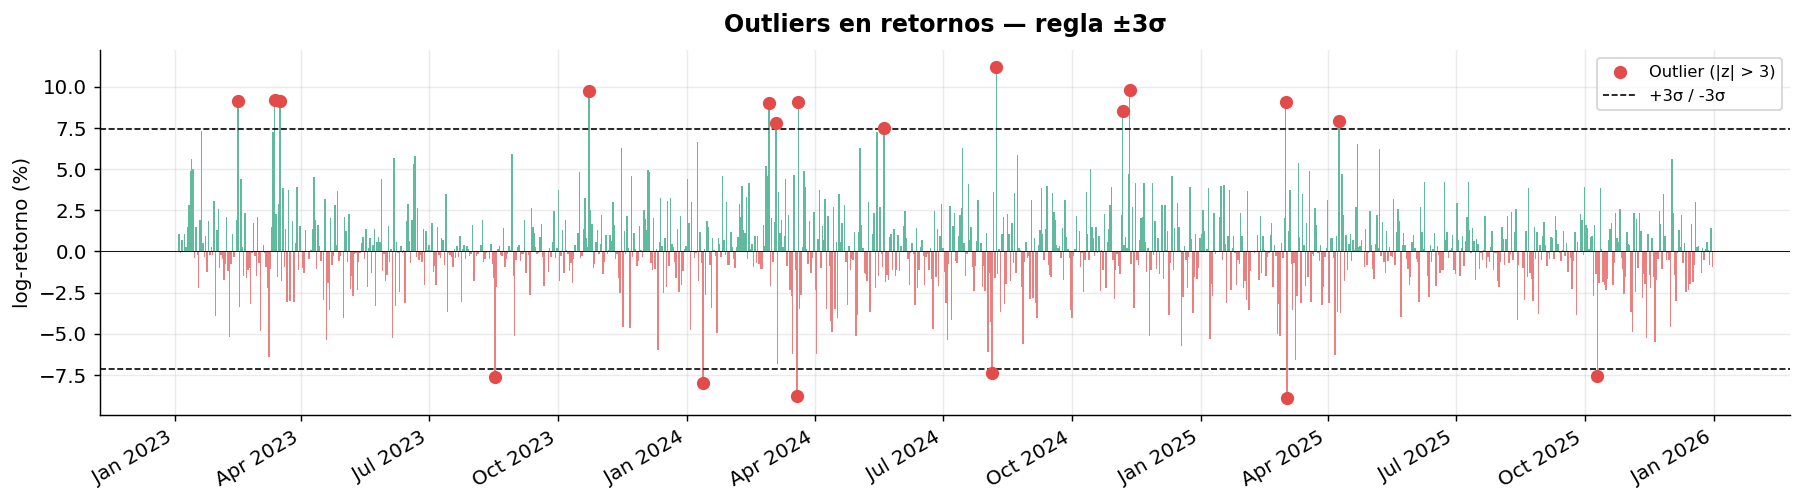

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Análisis de outliers y calidad de datos
# ─────────────────────────────────────────────────────────────────────────────
 
# ── 14a. Detección de outliers en retornos (regla ±3σ) ──────────────────────
SIGMA = 3
mu_r, sd_r   = ret.mean(), ret.std()
upper, lower = mu_r + SIGMA * sd_r, mu_r - SIGMA * sd_r
 
outliers = df_daily[["close", "log_ret"]].copy()
outliers["es_outlier"] = (ret > upper) | (ret < lower)
out_df = outliers[outliers["es_outlier"]].copy()
out_df["z_score"] = (out_df["log_ret"] - mu_r) / sd_r
 
print("=" * 55)
print(f"OUTLIERS — retornos fuera de ±{SIGMA}σ")
print("=" * 55)
print(f"Total detectados : {len(out_df)}")
print(f"% sobre muestra  : {len(out_df)/len(ret)*100:.2f}%\n")
print(out_df[["close", "log_ret", "z_score"]].round(4).to_string())
 
# Visualización outliers sobre serie de retornos
fig, ax = plt.subplots(figsize=(14, 4))
colors_bar = [COLOR_POS if r >= 0 else COLOR_NEG for r in ret]
ax.bar(df_daily.index, ret * 100, color=colors_bar, width=1, alpha=0.7)
ax.scatter(out_df.index, out_df["log_ret"] * 100,
           color=COLOR_OUT, zorder=5, s=40, label=f"Outlier (|z| > {SIGMA})")
ax.axhline(upper * 100, color="black", linestyle="--", linewidth=0.9,
           label=f"+{SIGMA}σ / -{SIGMA}σ")
ax.axhline(lower * 100, color="black", linestyle="--", linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_title(f"Outliers en retornos — regla ±{SIGMA}σ", fontweight="bold", pad=10)
ax.set_ylabel("log-retorno (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Análisis de Outliers en Retornos de Bitcoin (±3σ)

> **Total detectados:** 19 outliers — **1.74%** sobre la muestra total (Feb 2023 – Oct 2025)

---

- 1. Distribución Temporal

    Los outliers no se distribuyen de forma aleatoria a lo largo del período; aparecen en **clusters asociados a eventos fundamentales**:

    - **Feb–Mar 2023:** 3 outliers positivos consecutivos → rally de recuperación post-colapso FTX.
    - **Mar 2024:** 3 outliers en dos días (19–20 Mar) → alta volatilidad bidireccional en el ATH pre-halving.
    - **Nov 2024:** 2 outliers positivos seguidos → euforia tras las elecciones presidenciales de EE.UU.
    - **Mar 2025:** 2 outliers consecutivos de signo opuesto (+/−) → reversión brusca post-ATH.

- 2. Asimetría Direccional

    | Dirección | Cantidad | % del total |
    |-----------|:--------:|:-----------:|
    | Positivos (z > +3) | 13 | 68% |
    | Negativos (z < −3) | 6  | 32% |

    Los outliers positivos **duplican** a los negativos, lo que refleja un **sesgo alcista estructural** de Bitcoin durante el período analizado.

- 3. Outlier de Mayor Magnitud

    El retorno más extremo se registró el **8 de agosto de 2024** (z = 4.57, log-ret = +11.2%), correspondiente a un rebote violento inmediatamente después del crash del 5 de agosto (z = −3.11). Este patrón es característico de una **recuperación en "V"** (*V-recovery*), frecuente en activos de alta volatilidad tras liquidaciones masivas.

- 4. Catalizadores Fundamentales

    Cada cluster de outliers tiene una narrativa económica identificable:

    | Fecha | Evento |
    |-------|--------|
    | Feb–Mar 2023 | Recuperación post-FTX / narrativa de supervivencia de BTC |
    | Oct 2023 | Rumores de aprobación del ETF spot en EE.UU. |
    | Feb–Mar 2024 | Aprobación del ETF spot + anticipación del halving |
    | Ago 2024 | Flash crash macro global y rebote |
    | Nov 2024 | Victoria electoral de Trump (agenda pro-crypto) |
    | Mar 2025 | Corrección de sobrecompra post-ATH |

- 5. Implicaciones para el Modelado Estadístico

    - **Rechazo de la normalidad:** El 1.74% de outliers observados contrasta con el ≈0.27% esperado bajo una distribución normal, confirmando la presencia de **colas pesadas**. Se recomienda el uso de distribuciones alternativas como la **t-Student** o la **GEV** (*Generalized Extreme Value*).

    - **Efectos ARCH/GARCH:** La aparición de outliers en clusters es evidencia de **heterocedasticidad condicional** en la varianza, lo que justifica el uso de modelos de volatilidad estocástica.

    - **Outliers bidireccionales consecutivos:** Los pares de outliers de signo contrario en Mar 2024 y Mar 2025 indican que el mercado no se estabiliza de inmediato tras un shock extremo. Esto representa un **riesgo de *whipsaw*** para estrategias de reversión a la media.

- Conclusión

    Los outliers identificados no constituyen ruido aleatorio, sino **señales de eventos estructurales** vinculados a ciclos regulatorios, macroeconómicos y del halving de Bitcoin. Eliminarlos mecánicamente antes del modelado implica perder información crítica sobre la dinámica real del activo. El enfoque más robusto es modelarlos **explícitamente** mediante distribuciones de cola pesada o modelos de salto (*jump-diffusion models*).


CALIDAD DE DATOS — GAPS Y VALORES FALTANTES
Días esperados en el rango : 1094
Días presentes en el datos : 1094
Días faltantes             : 0
Sin gaps: cobertura diaria completa

Valores nulos por columna:
open       0
high       0
low        0
close      0
volume     0
trades     0
log_ret    0


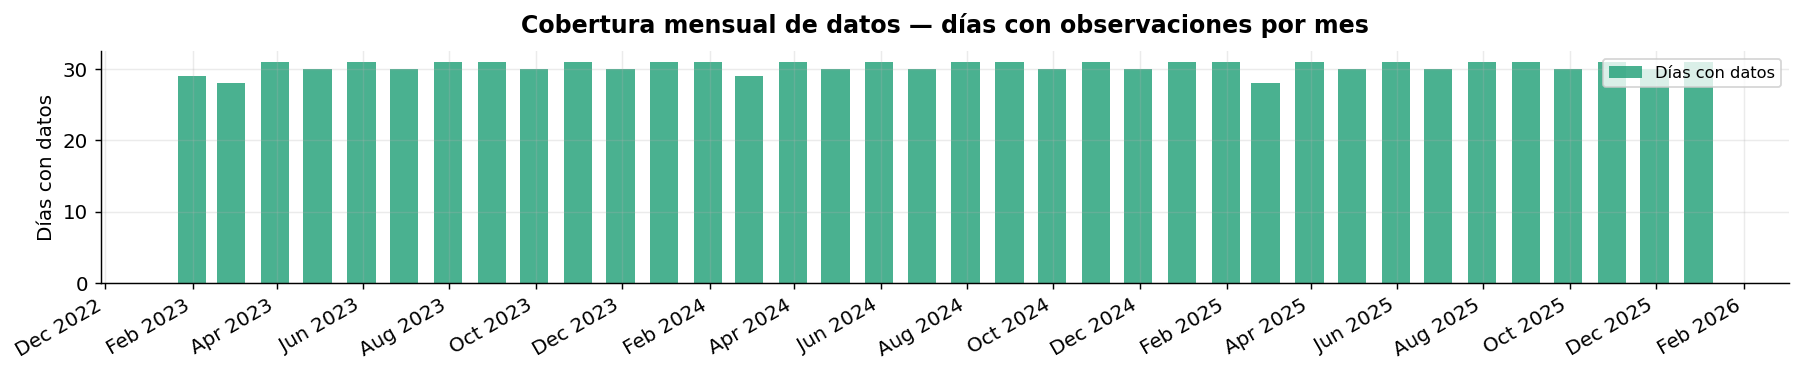

In [20]:
# ── 14b. Calidad de datos: gaps y valores faltantes ─────────────────────────
print("\n" + "=" * 55)
print("CALIDAD DE DATOS — GAPS Y VALORES FALTANTES")
print("=" * 55)
 
# Rango completo esperado
full_range = pd.date_range(
    start=df_daily.index.min(), end=df_daily.index.max(), freq="1D"
)
missing_days = full_range.difference(df_daily.index)
print(f"Días esperados en el rango : {len(full_range)}")
print(f"Días presentes en el datos : {len(df_daily)}")
print(f"Días faltantes             : {len(missing_days)}")
 
if len(missing_days) > 0:
    print("\nFechas faltantes:")
    for d in missing_days:
        print(f"  {d.date()}")
else:
    print("Sin gaps: cobertura diaria completa")
 
# Nulos por columna
print("\nValores nulos por columna:")
print(df_daily.isnull().sum().to_string())
 
# Visualización: mapa de presencia/ausencia por mes
df_daily["presente"] = 1
presence = df_daily["presente"].resample("ME").sum()
expected = df_daily.resample("ME").size().map(
    lambda x: pd.date_range("2000-01", periods=1, freq="ME")[0].days_in_month
)
 
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(presence.index, presence.values, color=COLOR_POS,
       alpha=0.8, width=20, label="Días con datos")
ax.set_title("Cobertura mensual de datos — días con observaciones por mes",
             fontweight="bold", pad=10)
ax.set_ylabel("Días con datos")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha="right")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
 
df_daily.drop(columns=["presente"], inplace=True)

Podemos observar que no hay huecos en el dataset y que se cubre completamente la cobertura mensual

se analiza la volatividad junto con los retornos

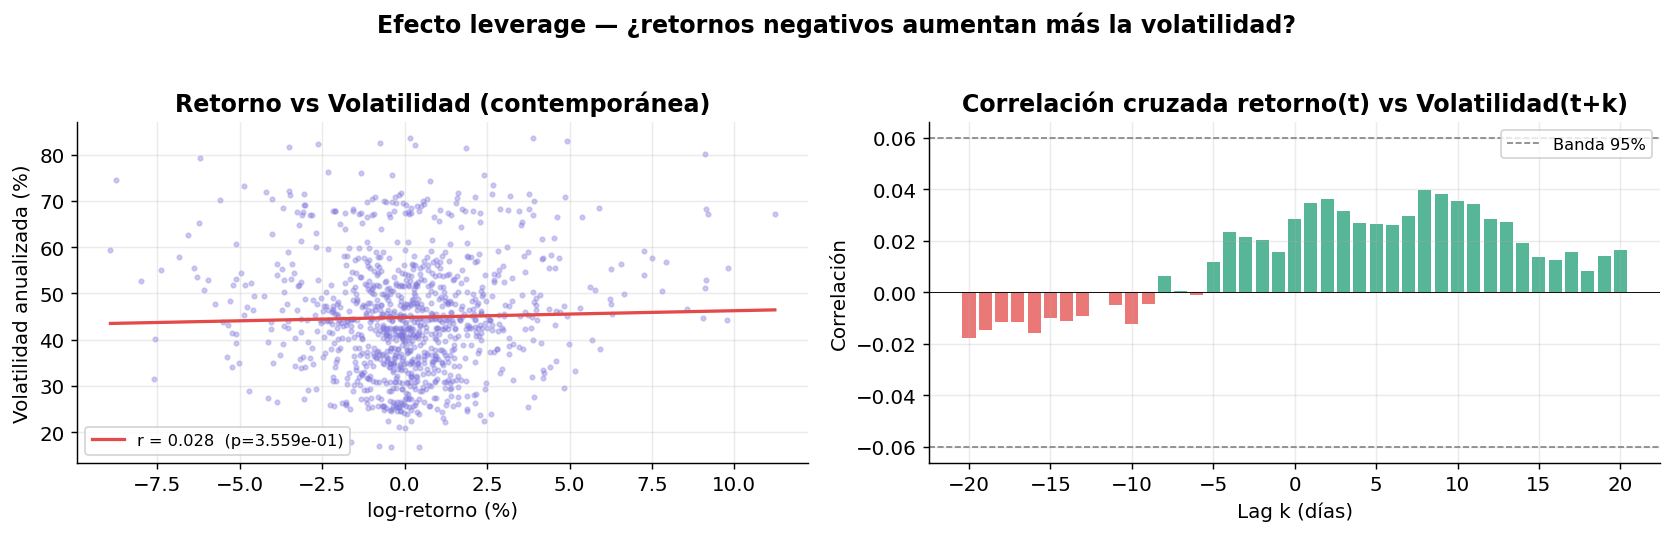


Volatilidad media tras retornos negativos : 44.61%
Volatilidad media tras retornos positivos : 45.04%
Ratio neg/pos : 0.990
→ Sin efecto leverage claro → GARCH simétrico puede ser suficiente


In [27]:
# Alineamos retornos con la volatilidad (vol tiene NaN en los primeros WINDOW_SIZE días)
aligned = df_daily[["log_ret", "Volatility"]].dropna().copy()
r_aligned   = aligned["log_ret"]
vol_aligned = aligned["Volatility"]
 
# ── 18a. Scatter retorno vs volatilidad ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
slope, intercept, r_val, p_val, _ = stats.linregress(r_aligned, vol_aligned)
x_fit = np.linspace(r_aligned.min(), r_aligned.max(), 200)
 
axes[0].scatter(r_aligned * 100, vol_aligned * 100,
                s=6, alpha=0.35, color=COLOR_HIST)
axes[0].plot(x_fit * 100, (slope * x_fit + intercept) * 100,
             color=COLOR_NEG, linewidth=1.8,
             label=f"r = {r_val:.3f}  (p={p_val:.3e})")
axes[0].set_title("Retorno vs Volatilidad (contemporánea)", fontweight="bold")
axes[0].set_xlabel("log-retorno (%)")
axes[0].set_ylabel("Volatilidad anualizada (%)")
axes[0].legend(fontsize=9)
 
# ── 18b. Correlación cruzada retorno(t) vs volatilidad(t+k) ─────────────────
MAX_CROSS = 20
cross_corr = [
    r_aligned.iloc[:len(r_aligned)-k].corr(vol_aligned.shift(-k).dropna())
    for k in range(-MAX_CROSS, MAX_CROSS + 1)
]
lags_cross = list(range(-MAX_CROSS, MAX_CROSS + 1))
cc_colors  = [COLOR_NEG if c < 0 else COLOR_POS for c in cross_corr]
 
axes[1].bar(lags_cross, cross_corr, color=cc_colors, alpha=0.75, width=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axhline( 1.96 / np.sqrt(len(r_aligned)), color="gray",
                linestyle="--", linewidth=0.9, label="Banda 95%")
axes[1].axhline(-1.96 / np.sqrt(len(r_aligned)), color="gray",
                linestyle="--", linewidth=0.9)
axes[1].set_title("Correlación cruzada retorno(t) vs Volatilidad(t+k)",
                  fontweight="bold")
axes[1].set_xlabel("Lag k (días)")
axes[1].set_ylabel("Correlación")
axes[1].legend(fontsize=9)
 
plt.suptitle("Efecto leverage — ¿retornos negativos aumentan más la volatilidad?",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
 
# Diagnóstico automático del efecto leverage
neg_ret_vol = vol_aligned[r_aligned < 0].mean()
pos_ret_vol = vol_aligned[r_aligned > 0].mean()
print(f"\nVolatilidad media tras retornos negativos : {neg_ret_vol*100:.2f}%")
print(f"Volatilidad media tras retornos positivos : {pos_ret_vol*100:.2f}%")
ratio = neg_ret_vol / pos_ret_vol
print(f"Ratio neg/pos : {ratio:.3f}")
if ratio > 1.05:
    print("→ Efecto leverage presente → usar GJR-GARCH o EGARCH")
else:
    print("→ Sin efecto leverage claro → GARCH simétrico puede ser suficiente")
 

Análisis del Efecto Leverage — Bitcoin (Binance 2023–2025)

La gráfica evalúa el **efecto leverage** en Bitcoin, es decir:

> ¿Los retornos negativos aumentan más la volatilidad que los retornos positivos?

Se analizan dos elementos:

- **Izquierda:** Retorno vs Volatilidad contemporánea  
- **Derecha:** Correlación cruzada retorno(t) vs volatilidad(t+k)

---

- 1 Retorno vs Volatilidad (Gráfica Izquierda)

- Observaciones

    - Nube de puntos dispersa sin patrón claro
    - Pendiente ligeramente positiva (casi plana)
    - Correlación muy baja:
        r = 0.028
        p = 0.3559

    Esto indica:
    - Relación muy débil entre retorno y volatilidad
    - No hay evidencia fuerte de efecto leverage
    - Retornos negativos no incrementan significativamente la volatilidad

    Esto es diferente a mercados tradicionales donde:

    - Caídas → Aumentan volatilidad
    - Subidas → Menor impacto en volatilidad

    Bitcoin parece más **simétrico**.

- 2 Correlación Cruzada Retorno vs Volatilidad (Gráfica Derecha)

- Observaciones

    - Lags negativos: correlación levemente negativa
    - Lags positivos: correlación levemente positiva
    - Magnitud baja (~0.02–0.04)
    - Dentro del intervalo de confianza del 95%

- Interpretación

    Esto indica:

    - Retornos negativos no generan aumento fuerte de volatilidad futura
    - Retornos positivos tampoco tienen impacto fuerte
    - Comportamiento aproximadamente simétrico

- 3 Métricas Clave

Volatilidad media tras retornos negativos : 44.61%
Volatilidad media tras retornos positivos : 45.04%
Ratio neg/pos : 0.990

- Interpretación:    
    - Diferencia prácticamente nula
    - Volatilidad casi igual tras subidas y bajadas
    - No hay evidencia clara de asimetría

**No hay efecto leverage significativo**

Esto implica:
-  Volatilidad simétrica
- Retornos negativos ≈ Retornos positivos
- Comportamiento distinto a acciones tradicionales


# TRANSICIÓN AL MODELADO
═══════════════════════════════════════════════════════════

El EDA se realizó en frecuencia DIARIA para facilitar la
interpretación de las propiedades estadísticas de la serie
(estacionariedad, autocorrelación, distribución, outliers).

El modelado (notebook 2) opera en frecuencia de 1 MINUTO:
  - Datos: btc_1m_2023_2025.csv (velas de 1 minuto)
  - Target: volatilidad calculada como rolling(1440).std()
    × sqrt(365), equivalente conceptual a la volatilidad
    diaria calculada en el EDA pero con mayor resolución
    temporal.
  - Features: lags de 15, 30, 60 y 90 minutos de historia.
  - Horizonte: 7 minutos hacia adelante (multisalida).

Justificación del resampleo en el EDA:
  La frecuencia diaria permite visualizar y testear las
  propiedades estructurales de la serie (tendencia, ciclos,
  clustering de volatilidad) sin el ruido de alta frecuencia
  de los datos de 1 minuto, que dificulta la interpretación
  visual y los tests estadísticos.
═══════════════════════════════════════════════════════════